In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("candidate_job_market_dataset1.csv")
df.shape

(120000, 31)

In [4]:
df.head()

,candidate_id,job_id,candidate_skills,education,years_experience,candidate_location,candidate_preferred_work_mode,job_title,required_skills,required_experience,...,student_internships,student_github_repos,student_hackathons_participated,student_coding_platform_rating,student_weekly_study_hours,student_career_label,student_experience_level,student_interests,fit_label,expected_salary_lpa
0,C000001,J000001,"SQL, Pandas, NumPy",MCA,0,Gurugram,On-site,Machine Learning Intern,"Python, Machine Learning, Pandas, NumPy, Sciki...",1,...,1.0,6.0,0.0,NaN,5.3,Software Engineer,Beginner,System Design,1,8.96
1,C000002,J000002,"Data Analysis, Tableau, Statistics, Excel, Pyt...",B.Tech,3,Mumbai,Hybrid,Data Analyst Intern,"Python, SQL, Excel, Power BI, Tableau, Data An...",1,...,1.0,2.0,1.0,NaN,12.0,ML Engineer,Intermediate,"Artificial Intelligence, Machine Learning",1,10.30
2,C000003,J000003,"Python, SQL, Data Analysis, Azure, JavaScript",B.Tech,4,Hyderabad,On-site,Python Developer Intern,"Python, Django, Flask, FastAPI, SQL, Git",1,...,0.0,3.0,2.0,1325.0,15.9,Data Scientist,Beginner,Statistics,0,11.35
3,C000004,J000004,"Python, SQL, Statistics, Excel, Tableau, JavaS...",M.Tech,1,Mumbai,Hybrid,Data Analyst Intern,"Python, SQL, Excel, Power BI, Tableau, Data An...",0,...,1.0,11.0,2.0,1893.0,5.9,Backend Developer,Intermediate,"Databases, Software Engineering",1,8.77
4,C000005,J000005,"Machine Learning, PyTorch, TensorFlow, NLP",B.Tech,0,Hyderabad,Remote,AI Intern,"Python, Machine Learning, Deep Learning, NLP, ...",0,...,1.0,7.0,2.0,NaN,10.5,ML Engineer,Intermediate,"Automation, Artificial Intelligence",1,8.16


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 31 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   candidate_id                     120000 non-null  object 
 1   job_id                           120000 non-null  object 
 2   candidate_skills                 120000 non-null  object 
 3   education                        120000 non-null  object 
 4   years_experience                 120000 non-null  int64  
 5   candidate_location               120000 non-null  object 
 6   candidate_preferred_work_mode    120000 non-null  object 
 7   job_title                        120000 non-null  object 
 8   required_skills                  120000 non-null  object 
 9   required_experience              120000 non-null  int64  
 10  job_location                     120000 non-null  object 
 11  work_mode                        120000 non-null  object 
 12  co

In [6]:
df.isnull().sum().sort_values(ascending=False)

student_certifications             35567
student_coding_platform_rating     27024
student_github_repos               13338
student_cgpa                       12327
student_weekly_study_hours         11067
student_interests                   8223
student_hackathons_participated     8207
student_internships                 6992
student_num_projects                5719
student_experience_level            3690
student_career_label                1618
education                              0
candidate_id                           0
job_id                                 0
candidate_skills                       0
job_duration_months                    0
industry                               0
company_size                           0
work_mode                              0
job_location                           0
required_experience                    0
required_skills                        0
job_title                              0
candidate_preferred_work_mode          0
candidate_locati

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.nunique().sort_values()

fit_label                               2
candidate_preferred_work_mode           3
work_mode                               3
required_experience                     3
student_experience_level                3
student_year_of_study                   4
job_duration_months                     4
company_size                            5
student_internships                     5
education                               5
years_experience                        5
student_hackathons_participated         7
skill_overlap                           7
job_title                               8
industry                                8
required_skills                         8
student_num_projects                    9
candidate_location                     10
job_location                           10
student_career_label                   11
skill_coverage                         16
student_github_repos                   30
student_interests                     136
student_weekly_study_hours        

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
years_experience,120000.0,1.998192,1.413868,0.000,1.000,2.000,3.000,4.00
required_experience,120000.0,0.994675,0.816773,0.000,0.000,1.000,2.000,2.00
job_duration_months,120000.0,3.939425,1.463930,2.000,3.000,3.000,6.000,6.00
skill_overlap,120000.0,3.452450,1.555381,1.000,2.000,3.000,5.000,7.00
skill_coverage,120000.0,0.575251,0.253735,0.143,0.333,0.571,0.833,1.00
student_year_of_study,120000.0,2.619667,0.926420,1.000,2.000,3.000,3.000,4.00
student_cgpa,107673.0,7.703439,0.888063,5.000,7.100,7.700,8.300,9.90
student_num_projects,114281.0,2.702899,1.826710,0.000,1.000,2.000,4.000,8.00
student_internships,113008.0,0.653556,0.904657,0.000,0.000,0.000,1.000,4.00
student_github_repos,106662.0,8.444873,4.683460,0.000,5.000,8.000,11.000,31.00


### CATEGORICAL CONSISTENCY

In [10]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['candidate_id', 'job_id', 'candidate_skills', 'education',
       'candidate_location', 'candidate_preferred_work_mode', 'job_title',
       'required_skills', 'job_location', 'work_mode', 'company_size',
       'industry', 'student_certifications', 'student_career_label',
       'student_experience_level', 'student_interests'],
      dtype='object')

In [11]:
for col in cat_cols:
    print("\nColumn:", col)
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts(dropna=False).head(15))


Column: candidate_id
Unique values: 120000
candidate_id
C000001    1
C000002    1
C000003    1
C000004    1
C000005    1
C000006    1
C000007    1
C000008    1
C000009    1
C000010    1
C000011    1
C000012    1
C000013    1
C000014    1
C000015    1
Name: count, dtype: int64

Column: job_id
Unique values: 120000
job_id
J000001    1
J000002    1
J000003    1
J000004    1
J000005    1
J000006    1
J000007    1
J000008    1
J000009    1
J000010    1
J000011    1
J000012    1
J000013    1
J000014    1
J000015    1
Name: count, dtype: int64

Column: candidate_skills
Unique values: 76437
candidate_skills
Python              465
SQL                 403
Git                 326
Machine Learning    190
Docker              145
NumPy               140
Pandas              139
Python, SQL         139
Java                137
HTML                137
CSS                 133
SQL, Python         133
JavaScript          131
React               128
Flask               100
Name: count, dtype: int64

Colum

In [12]:
print("Candidate Skills:")
print(df['candidate_skills'].value_counts(dropna=False).head(15))

Candidate Skills:
candidate_skills
Python              465
SQL                 403
Git                 326
Machine Learning    190
Docker              145
NumPy               140
Pandas              139
Python, SQL         139
Java                137
HTML                137
CSS                 133
SQL, Python         133
JavaScript          131
React               128
Flask               100
Name: count, dtype: int64


In [13]:
df['candidate_skills'] = df['candidate_skills'].replace({
    'SQL, Python': 'Python, SQL'
})

In [14]:
df['candidate_skills'].value_counts().head(15)

candidate_skills
Python              465
SQL                 403
Git                 326
Python, SQL         272
Machine Learning    190
Docker              145
NumPy               140
Pandas              139
Java                137
HTML                137
CSS                 133
JavaScript          131
React               128
Flask               100
Statistics           97
Name: count, dtype: int64

In [15]:
print("Student Interests:")
print(df['student_interests'].value_counts(dropna=False).head(15))

Student Interests:
student_interests
NaN                                    8223
Artificial Intelligence                3500
Analytics                              2857
System Design                          2375
Automation                             1913
Software Engineering                   1887
System Design, Software Engineering    1513
Data Science                           1465
Statistics                             1374
UI, UX                                 1308
Data Visualization                     1255
Business Analytics                     1229
Business Analytics, Analytics          1213
MLOps                                  1168
Competitive Programming                1137
Name: count, dtype: int64


In [16]:
df['student_interests'] = df['student_interests'].replace({
    'Business Analytics, Analytics': 'Business Analytics'
})

In [17]:
df['student_interests'].value_counts().head(15)

student_interests
Artificial Intelligence                3500
Analytics                              2857
Business Analytics                     2442
System Design                          2375
Automation                             1913
Software Engineering                   1887
System Design, Software Engineering    1513
Data Science                           1465
Statistics                             1374
UI, UX                                 1308
Data Visualization                     1255
MLOps                                  1168
Competitive Programming                1137
Statistics, Data Science               1128
Startups                               1112
Name: count, dtype: int64

### LOGICAL &REFERENTIAL CHECKS

In [18]:
df[['years_experience', 'required_experience']].describe()

,years_experience,required_experience
count,120000.000000,120000.000000
mean,1.998192,0.994675
std,1.413868,0.816773
min,0.000000,0.000000
25%,1.000000,0.000000
50%,2.000000,1.000000
75%,3.000000,2.000000
max,4.000000,2.000000


In [19]:
(df['years_experience'] < df['required_experience']).sum()

np.int64(23756)

In [20]:
(df['years_experience'] < 0).sum()

np.int64(0)

In [21]:
(df['years_experience'] < 0).sum()

np.int64(0)

In [22]:
(df['required_experience'] < 0).sum()

np.int64(0)

In [23]:
(df['student_cgpa'] < 0).sum(), (df['student_cgpa'] > 10).sum()

(np.int64(0), np.int64(0))

In [24]:
(df['student_num_projects'] < 0).sum()

np.int64(0)

In [25]:
(df['student_internships'] < 0).sum()

np.int64(0)

In [26]:
(df['student_hackathons_participated'] < 0).sum()

np.int64(0)

In [27]:
(df['student_weekly_study_hours'] < 0).sum()

np.int64(347)

In [28]:
df.loc[df['student_weekly_study_hours'] < 0, 'student_weekly_study_hours'] = 0

In [29]:
(df['student_weekly_study_hours'] < 0).sum()

np.int64(0)

### outliers 

In [30]:
num_cols = df.select_dtypes(include='number').columns
num_cols

Index(['years_experience', 'required_experience', 'job_duration_months',
       'skill_overlap', 'skill_coverage', 'student_year_of_study',
       'student_cgpa', 'student_num_projects', 'student_internships',
       'student_github_repos', 'student_hackathons_participated',
       'student_coding_platform_rating', 'student_weekly_study_hours',
       'fit_label', 'expected_salary_lpa'],
      dtype='object')

In [31]:
sk = df[num_cols].skew().sort_values(ascending=False)
sk

student_weekly_study_hours         12.401421
student_coding_platform_rating     11.380122
student_internships                 1.477269
student_hackathons_participated     1.088721
student_github_repos                0.772019
student_num_projects                0.632408
job_duration_months                 0.383073
skill_overlap                       0.095275
skill_coverage                      0.013784
expected_salary_lpa                 0.013045
required_experience                 0.009786
student_cgpa                        0.007810
years_experience                   -0.000182
student_year_of_study              -0.064217
fit_label                          -0.408253
dtype: float64

In [32]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
count = ((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))).sum()

count.sort_values(ascending=False)

student_internships                5392
student_github_repos               1597
student_weekly_study_hours         1158
expected_salary_lpa                 626
student_coding_platform_rating      534
student_cgpa                        239
student_hackathons_participated     220
student_year_of_study                 0
skill_coverage                        0
skill_overlap                         0
job_duration_months                   0
years_experience                      0
required_experience                   0
student_num_projects                  0
fit_label                             0
dtype: int64

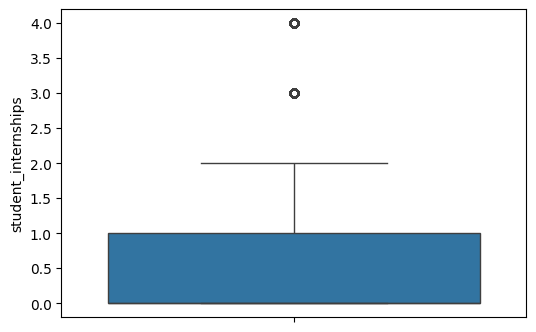

In [33]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['student_internships'])
plt.show()

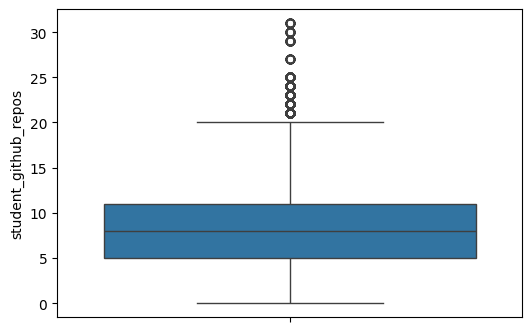

In [34]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['student_github_repos'])
plt.show()

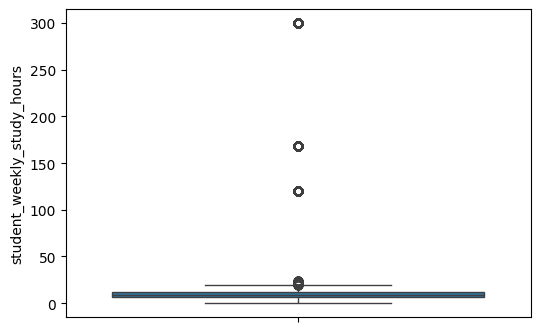

In [35]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['student_weekly_study_hours'])
plt.show()

In [36]:
Q1 = df['student_weekly_study_hours'].quantile(0.25)
Q3 = df['student_weekly_study_hours'].quantile(0.75)
IQR = Q3 - Q1
low = Q1 - 1.5 * IQR
high = Q3 + 1.5 * IQR

df['student_weekly_study_hours'] = df['student_weekly_study_hours'].clip(low, high)

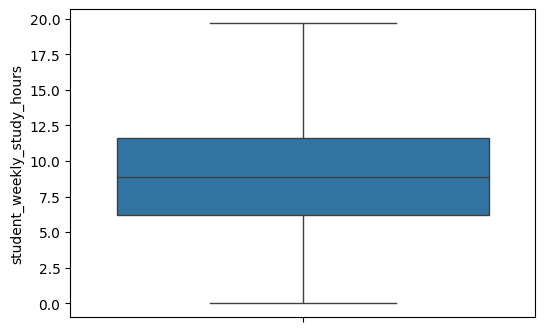

In [37]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['student_weekly_study_hours'])
plt.show()

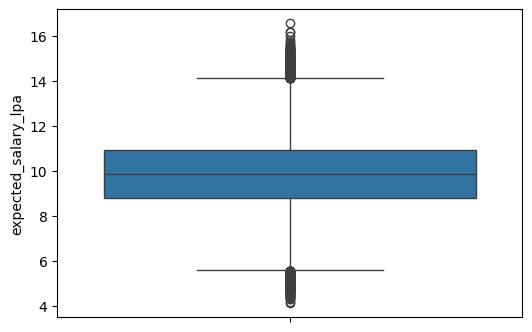

In [38]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['expected_salary_lpa'])
plt.show()

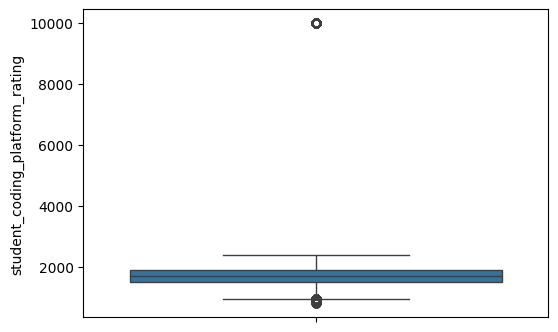

In [39]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['student_coding_platform_rating'])
plt.show()

In [40]:
Q1 = df['student_coding_platform_rating'].quantile(0.25)
Q3 = df['student_coding_platform_rating'].quantile(0.75)

IQR = Q3 - Q1

low = Q1 - 1.5 * IQR
high = Q3 + 1.5 * IQR

df['student_coding_platform_rating'] = df['student_coding_platform_rating'].clip(low, high)

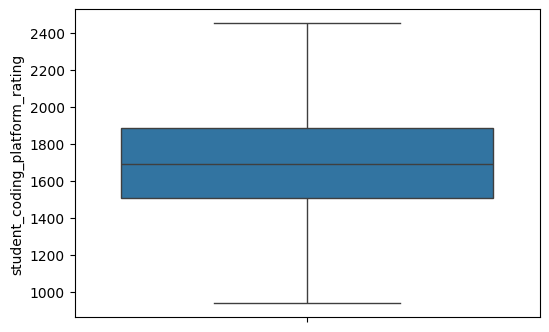

In [41]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['student_coding_platform_rating'])
plt.show()

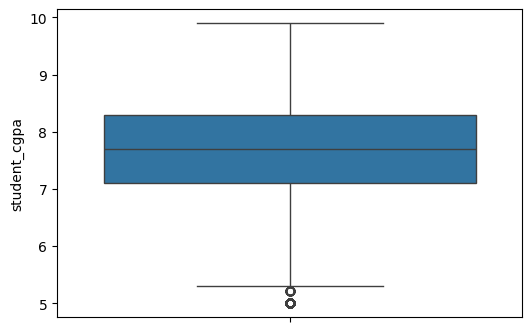

In [42]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['student_cgpa'])
plt.show()

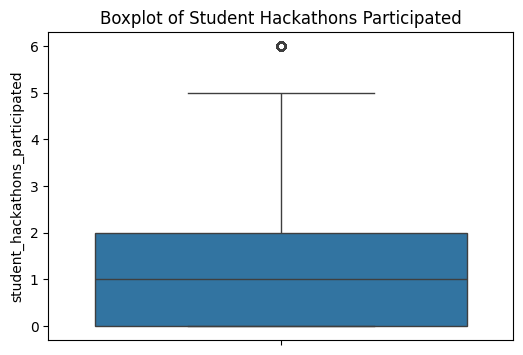

In [43]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['student_hackathons_participated'])
plt.title('Boxplot of Student Hackathons Participated')
plt.show()

In [44]:
sk = df[num_cols].skew().sort_values(ascending=False)
sk

student_internships                1.477269
student_hackathons_participated    1.088721
student_github_repos               0.772019
student_num_projects               0.632408
job_duration_months                0.383073
student_weekly_study_hours         0.114413
skill_overlap                      0.095275
skill_coverage                     0.013784
expected_salary_lpa                0.013045
required_experience                0.009786
student_cgpa                       0.007810
years_experience                  -0.000182
student_coding_platform_rating    -0.006022
student_year_of_study             -0.064217
fit_label                         -0.408253
dtype: float64

### missing values treatment

In [45]:
df.select_dtypes(include='number').isnull().sum().sort_values(ascending=False)

student_coding_platform_rating     27024
student_github_repos               13338
student_cgpa                       12327
student_weekly_study_hours         11067
student_hackathons_participated     8207
student_internships                 6992
student_num_projects                5719
student_year_of_study                  0
skill_coverage                         0
skill_overlap                          0
job_duration_months                    0
years_experience                       0
required_experience                    0
fit_label                              0
expected_salary_lpa                    0
dtype: int64

In [46]:
df['student_coding_platform_rating'] = df['student_coding_platform_rating'].fillna(df['student_coding_platform_rating'].median())

In [47]:
df['student_coding_platform_rating'].isnull().sum()

np.int64(0)

In [48]:
df['student_github_repos'] = df['student_github_repos'].fillna(df['student_github_repos'].median())

In [49]:
df['student_github_repos'].isnull().sum()

np.int64(0)

In [50]:
df['student_cgpa'] = df['student_cgpa'].fillna(df['student_cgpa'].mean())

In [51]:
df['student_cgpa'].isnull().sum()

np.int64(0)

In [52]:
df['student_weekly_study_hours'] = df['student_weekly_study_hours'].fillna(df['student_weekly_study_hours'].median())

In [53]:
df['student_weekly_study_hours'].isnull().sum()

np.int64(0)

In [54]:
df['student_hackathons_participated'] = df['student_hackathons_participated'].fillna(df['student_hackathons_participated'].median())

In [55]:
df['student_hackathons_participated'].isnull().sum()

np.int64(0)

In [56]:
df['student_internships'] = df['student_internships'].fillna(df['student_internships'].median())

In [57]:
df['student_internships'].isnull().sum()

np.int64(0)

In [58]:
df['student_num_projects'] = df['student_num_projects'].fillna(df['student_num_projects'].median())

In [59]:
df['student_num_projects'].isnull().sum()

np.int64(0)

In [60]:
df.select_dtypes(include='number').isnull().sum().sort_values(ascending=False)

years_experience                   0
required_experience                0
job_duration_months                0
skill_overlap                      0
skill_coverage                     0
student_year_of_study              0
student_cgpa                       0
student_num_projects               0
student_internships                0
student_github_repos               0
student_hackathons_participated    0
student_coding_platform_rating     0
student_weekly_study_hours         0
fit_label                          0
expected_salary_lpa                0
dtype: int64

In [61]:
df.select_dtypes(include='object').isnull().sum().sort_values(ascending=False)

student_certifications           35567
student_interests                 8223
student_experience_level          3690
student_career_label              1618
candidate_id                         0
job_id                               0
candidate_skills                     0
education                            0
required_skills                      0
job_title                            0
candidate_preferred_work_mode        0
candidate_location                   0
industry                             0
company_size                         0
work_mode                            0
job_location                         0
dtype: int64

In [62]:
df['student_certifications'].value_counts(dropna=False)

student_certifications
NaN                                                                              35567
Google Data Analytics                                                             2891
Coursera ML Specialization                                                        2463
TensorFlow Developer                                                              1895
Oracle Java SE                                                                    1851
                                                                                 ...  
Docker Certified; AZ-900; Google Cloud Associate                                    23
HackerRank Problem Solving, NPTEL DSA, Coursera DSA                                 22
Oracle Java SE, Meta Back-End, Postman API Fundamentals                             22
Udemy MERN; freeCodeCamp Responsive Web; JavaScript Algorithms (freeCodeCamp)       22
AWS Cloud Practitioner; AZ-900; Docker Certified; Google Cloud Associate            20
Name: count, Length:

In [63]:
df['student_certifications'] = df['student_certifications'].fillna('Not Provided')

In [64]:
df['student_interests'].value_counts(dropna=False)

student_interests
NaN                               8223
Artificial Intelligence           3500
Analytics                         2857
Business Analytics                2442
System Design                     2375
                                  ... 
Computer Vision, Generative AI     326
Cyber Security, Privacy            325
CTF, Cyber Security                323
APIs, Software Engineering         322
Privacy, CTF                       309
Name: count, Length: 136, dtype: int64

In [65]:
df['student_interests'] = df['student_interests'].fillna('Not Provided')

In [66]:
df['student_experience_level'].value_counts(dropna=False)

student_experience_level
Beginner        62227
Intermediate    38943
Advanced        15140
NaN              3690
Name: count, dtype: int64

In [67]:
df['student_experience_level'] = df['student_experience_level'].fillna(df['student_experience_level'].mode()[0])

In [68]:
df['student_career_label'].value_counts(dropna=False)

student_career_label
Data Scientist           18058
Data Analyst             15358
Software Engineer        14611
Backend Developer        12638
ML Engineer              12270
Cloud/DevOps Engineer    11674
AI Engineer              10672
Cybersecurity Analyst     8594
Web Developer             8417
Frontend Developer        3172
Full Stack Developer      2918
NaN                       1618
Name: count, dtype: int64

In [69]:
df['student_career_label'] = df['student_career_label'].fillna('Not Provided')

In [70]:
df.select_dtypes(include='object').isnull().sum().sort_values(ascending=False)

candidate_id                     0
job_id                           0
candidate_skills                 0
education                        0
candidate_location               0
candidate_preferred_work_mode    0
job_title                        0
required_skills                  0
job_location                     0
work_mode                        0
company_size                     0
industry                         0
student_certifications           0
student_career_label             0
student_experience_level         0
student_interests                0
dtype: int64

## EDA :-

[Text(0, 0, '465'),
 Text(0, 0, '403'),
 Text(0, 0, '326'),
 Text(0, 0, '272'),
 Text(0, 0, '190')]

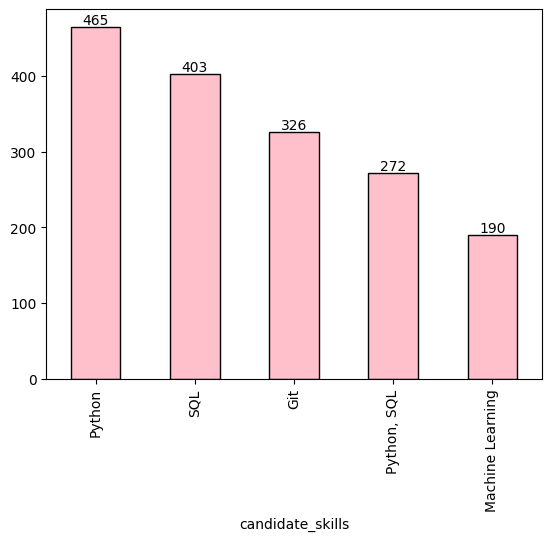

In [71]:
ax=df["candidate_skills"].value_counts().head(5).plot(kind='bar',color='pink',edgecolor="black")
ax.bar_label(ax.containers[0])

- MOST OF STUDENT CARRIES THESE SKILL SET.(ie-Top 5 Most common skill sets).

<Axes: ylabel='count'>

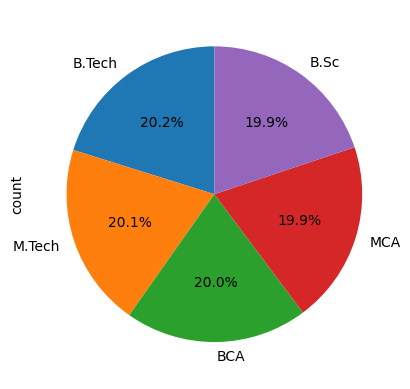

In [72]:
df["education"].value_counts().plot(kind="pie",autopct='%1.1f%%',startangle=90)

- BCA , B-TECH , M.TECH , MCA , BSC. All 5 have almost same distribution in Education.  

C:\Users\cdeva\AppData\Local\Temp\ipykernel_14144\1860981328.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=df,x="years_experience",palette="viridis")


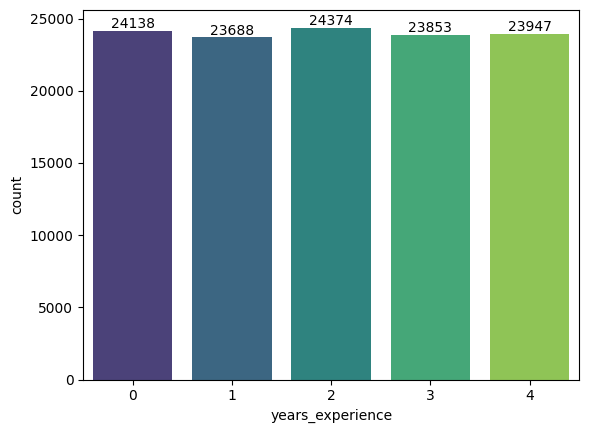

In [73]:
ax=sns.countplot(data=df,x="years_experience",palette="viridis")
for container in ax.containers:
    ax.bar_label(container)

- Candidate With 2 Year Experience is most but there is not such a large difference between no of candidate have year of experience 0,1,3,4. 

[Text(0, 0, '12209'), Text(0, 0, '12127'), Text(0, 0, '12065')]

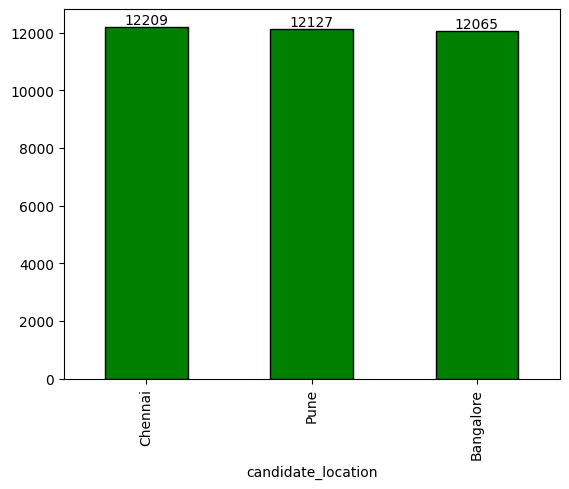

In [74]:
ax=df["candidate_location"].value_counts().head(3).plot(kind="bar",color="green",edgecolor="black")
ax.bar_label(ax.containers[0])

- Most of Candidate Belong to Big Cities ie-Chennai > Pune > Banglore .

<Axes: ylabel='count'>

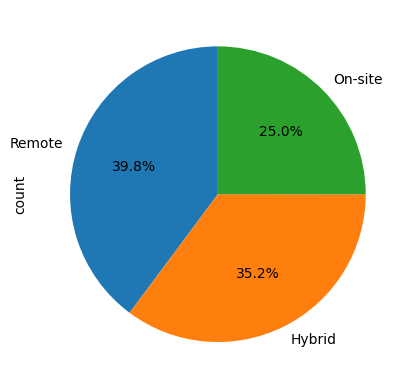

In [75]:
df["candidate_preferred_work_mode"].value_counts().plot(kind="pie",autopct="%1.1f%%",startangle=90)

- Candidate Mostly Prefer Remote Jobs/Hybrid .Main Reson behind this may be they want quite and noisy free enviroment.

[Text(0, 0, '15213'),
 Text(0, 0, '15126'),
 Text(0, 0, '15077'),
 Text(0, 0, '14996'),
 Text(0, 0, '14990')]

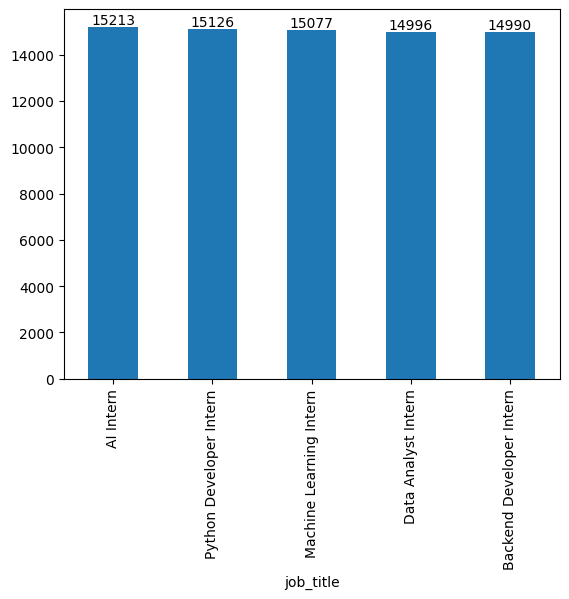

In [76]:
ax=df["job_title"].value_counts().head(5).plot(kind="bar")
ax.bar_label(ax.containers[0])

- The Above Graph show Most of candidates with these job post.  

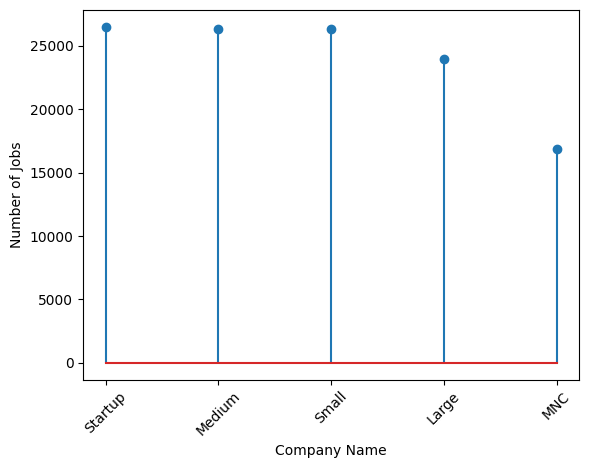

In [77]:
df["company_size"]=df["company_size"].replace({"Medium (201-1000)":"Medium","Large (1001-10000)":"Large","Enterprise (10000+)":"MNC","Startup (1-50)":"Startup","Small (51-200)":"Small"})
top = df["company_size"].value_counts().head(5)
plt.stem(top.index,top.values)
plt.xlabel("Company Name")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.show()

- Startup Provde lagest No of Job Whereas MNC Provide few as comapare to startup.

Text(0, 0.5, 'NO of job')

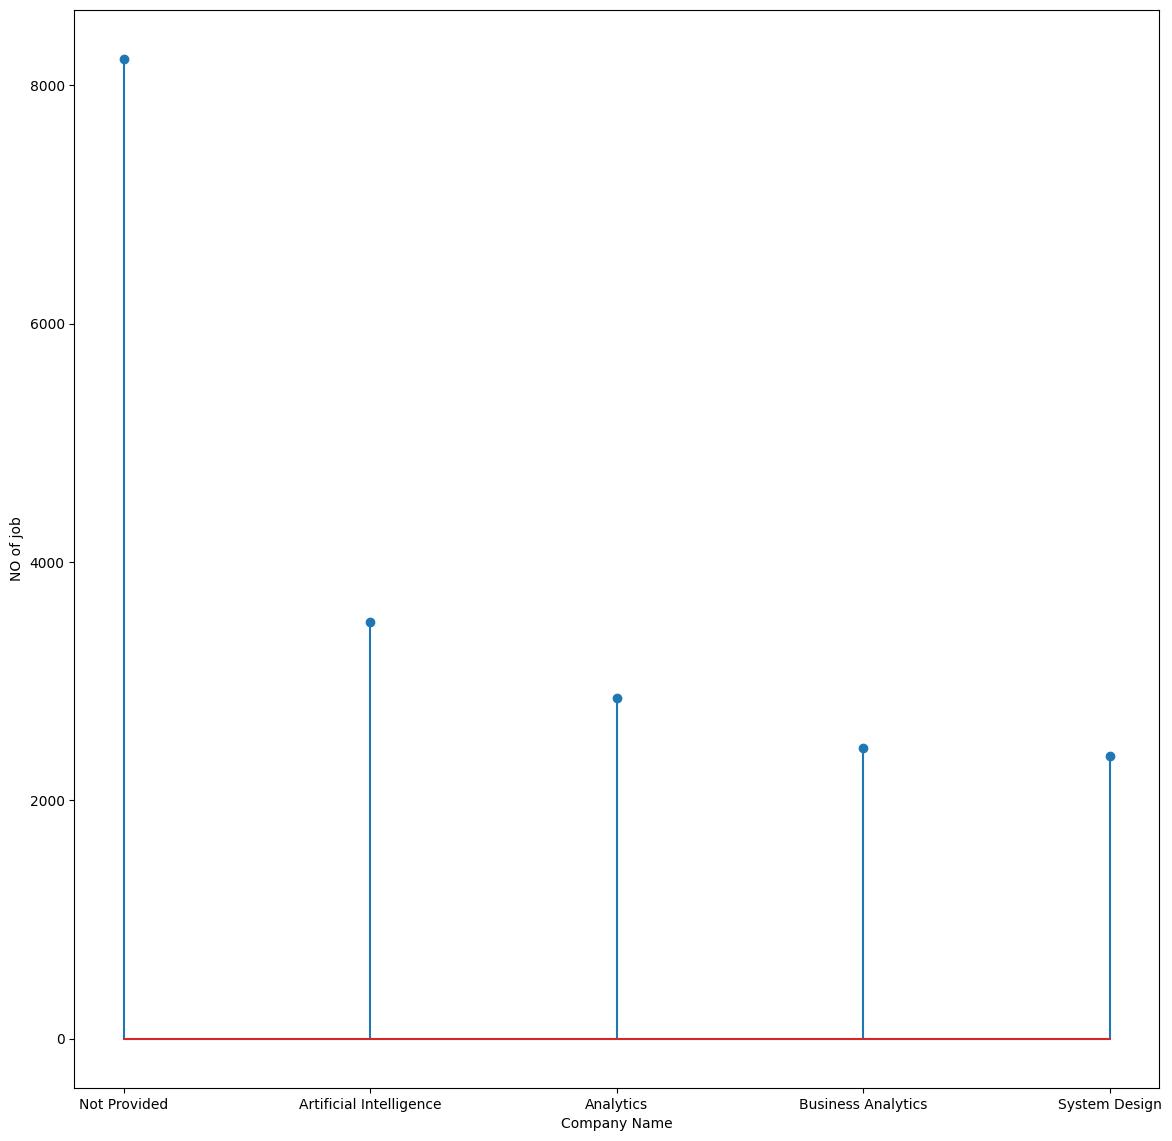

In [78]:
plt.figure(figsize=(14,14))
A=df["student_interests"].value_counts().sort_values(ascending=False).head(5)

plt.stem(A.index,A.values)
plt.xlabel("Company Name")
plt.ylabel("NO of job")

- Most of Student are not stated In Which Domain They are interested May be they are confuse 
  Whereas Most Of student States that Ai As a interest.

<Axes: >

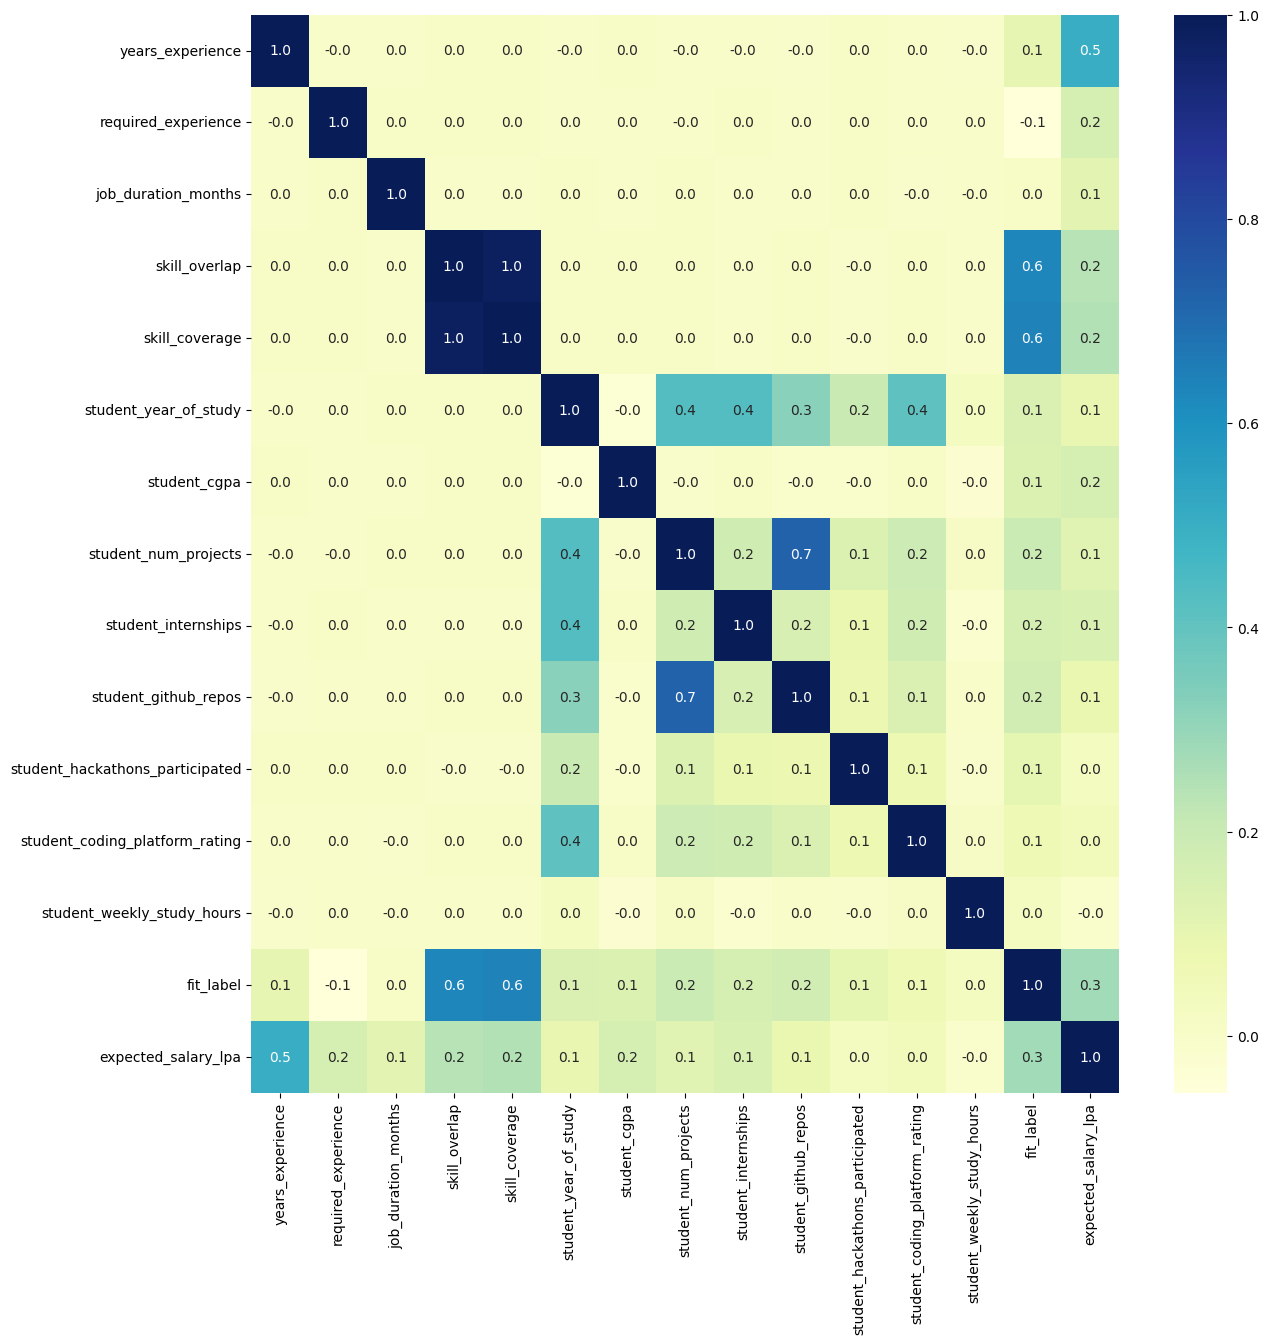

In [79]:
plt.figure(figsize=(14,14))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt=".1f",cmap="YlGnBu")

- Column Which highest corelation amoung them :-

- 1- > Year_Experience v/S Expected Salary
- 2- > skill overlap,skillconverge vs fit label
- 3- > student_year_of_study vs student no of project/student internship/student coding platform rating 
- 4- > student no project vs student git repos  

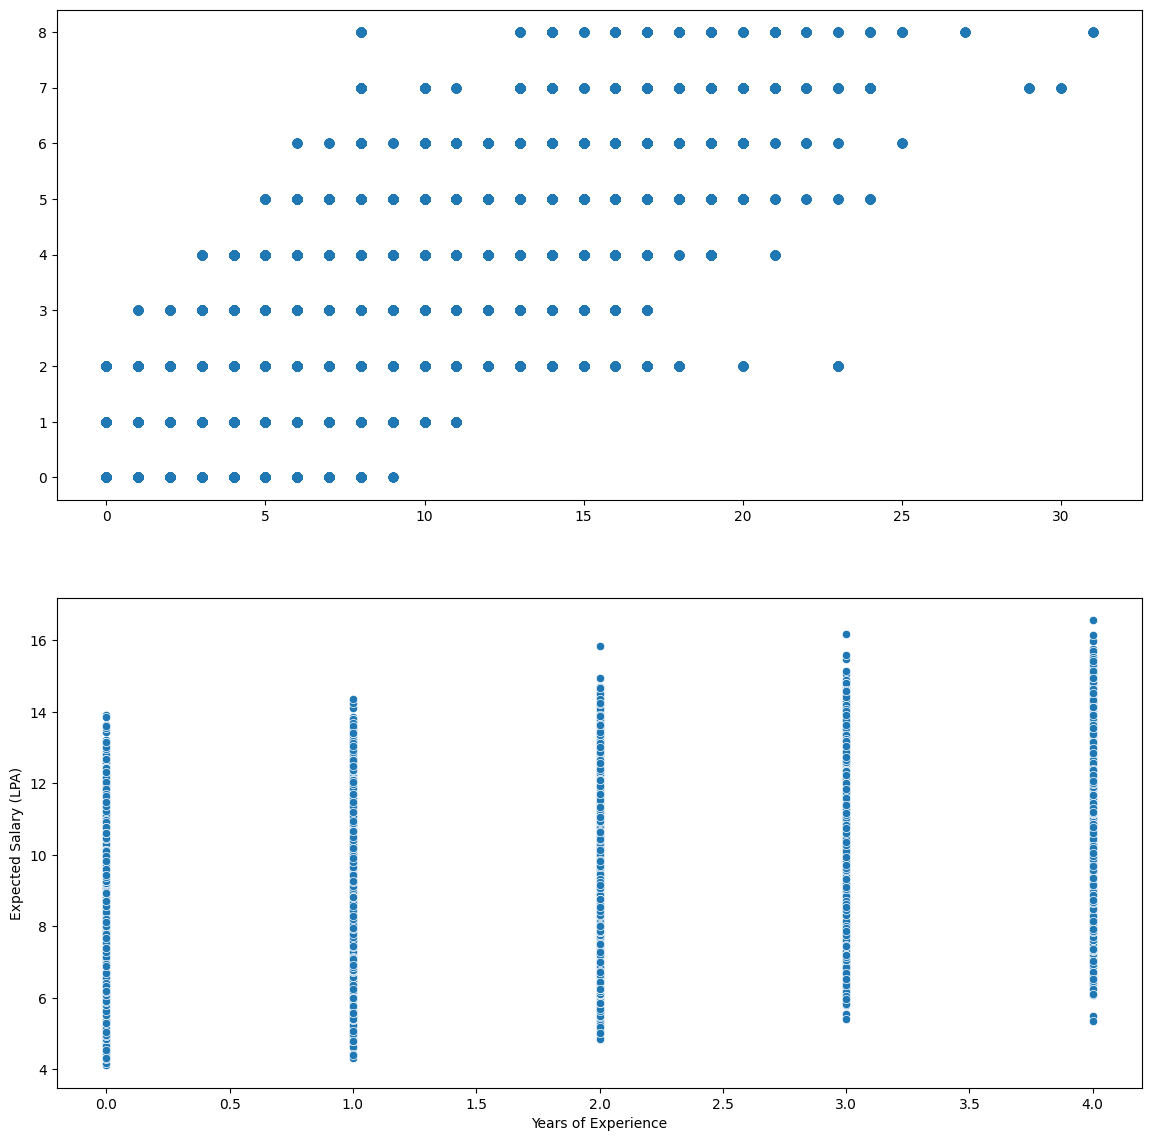

In [86]:
plt.figure(figsize=(14,14))
plt.subplot(2,1,1)
plt.scatter(df["student_github_repos"],df["student_num_projects"])

plt.subplot(2,1,2)
sns.scatterplot(data=df,x="years_experience",y="expected_salary_lpa")
plt.xlabel("Years of Experience")
plt.ylabel("Expected Salary (LPA)")
plt.show()

<Axes: xlabel='expected_salary_lpa', ylabel='Density'>

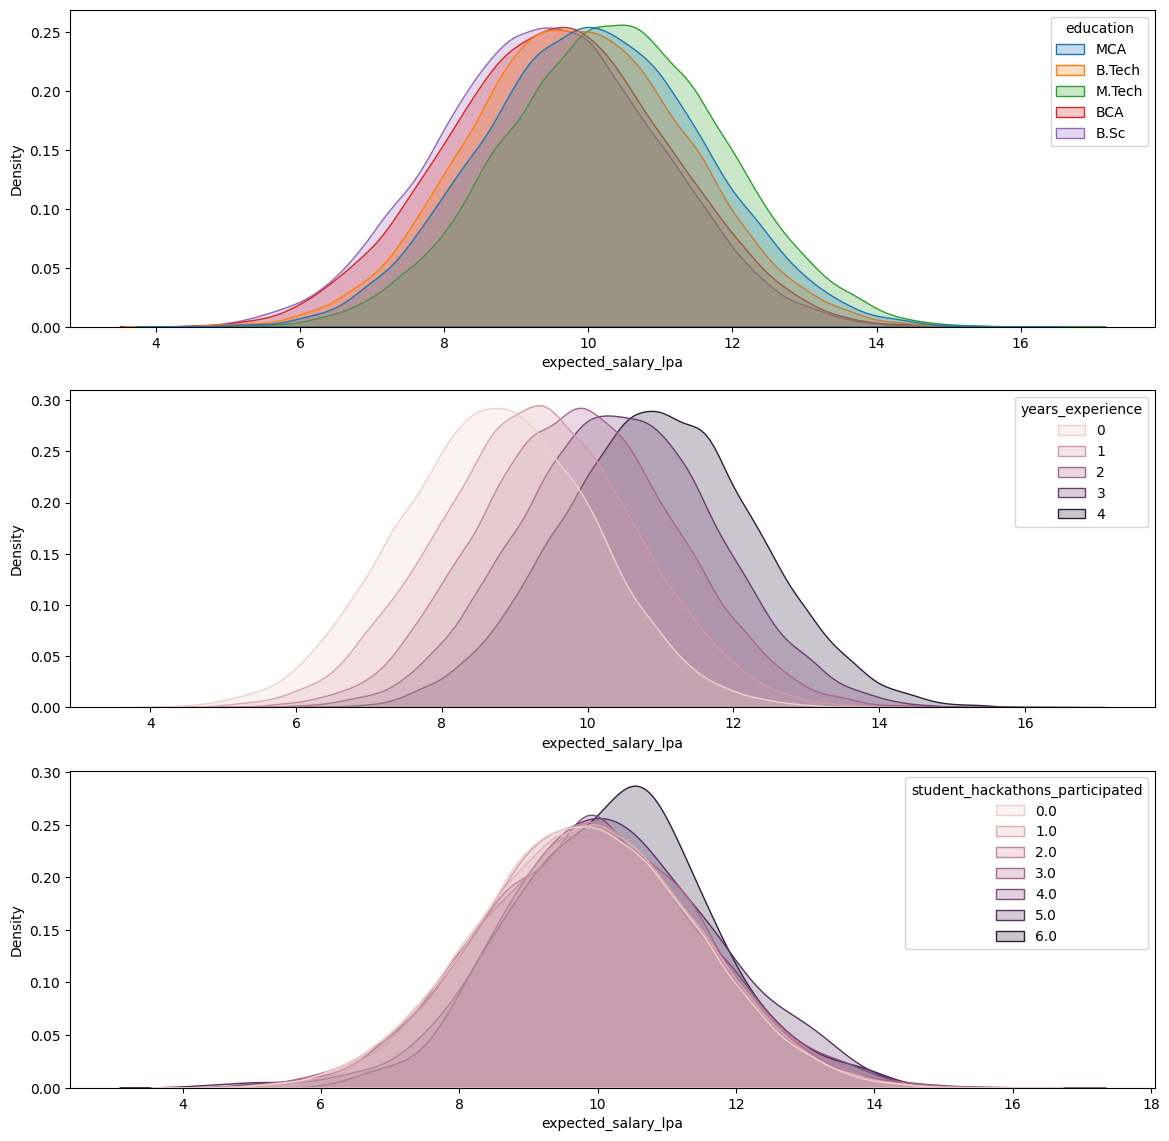

In [93]:
plt.figure(figsize=(14,14))
plt.subplot(3,1,1)
sns.kdeplot(data=df,x="expected_salary_lpa",hue="education",fill=True,common_norm=False)

plt.subplot(3,1,2)
sns.kdeplot(data=df,x="expected_salary_lpa",hue="years_experience",fill=True,common_norm=False)

plt.subplot(3,1,3)
sns.kdeplot(data=df,x="expected_salary_lpa",hue="student_hackathons_participated",fill=True,common_norm=False)


<Axes: xlabel='job_location', ylabel='expected_salary_lpa'>

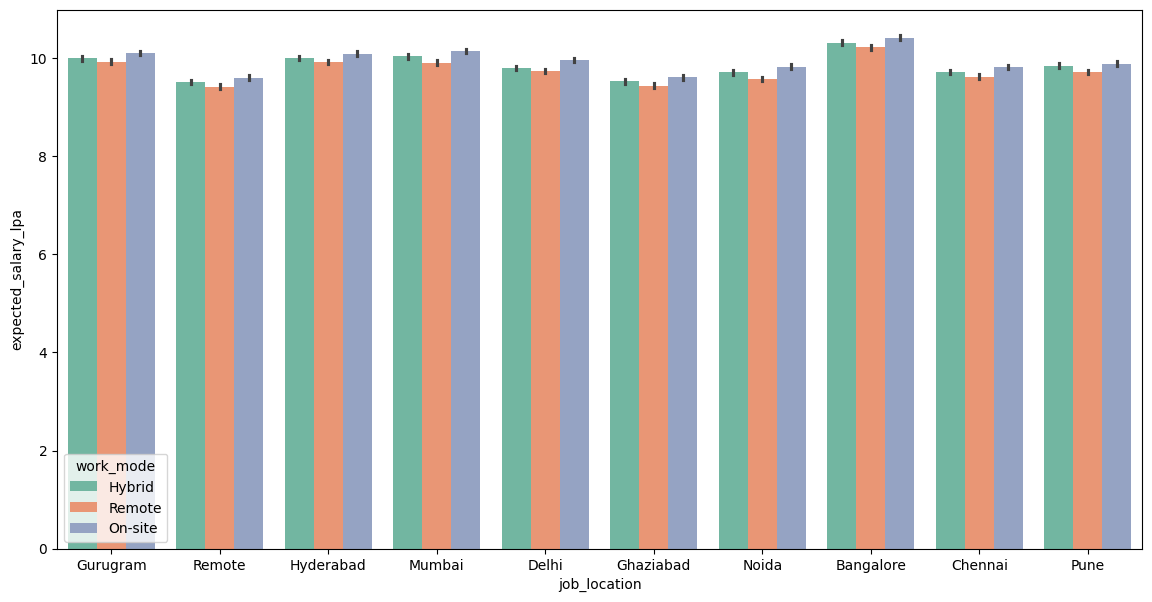

In [100]:
plt.figure(figsize=(14,7))
sns.barplot(data=df,x="job_location",y="expected_salary_lpa",hue="work_mode",palette='Set2')